# PhysioNet EEGBCI Main Analysis

This is a companion tutorial to the paper *“A Primer on Low-Dimensional Neural Dynamics: PCA-Based Trajectory Analysis for EEG and MEG.”* 

In this notebook, we walk through the **10-step PCA trajectory workflow** outlined in the paper. We apply it to a 10-subject slice of the PhysioNet EEGBCI motor imagery dataset, ultimately showing how to export your results to an interactive HTML report.

<div class="alert alert-secondary">
<b>🗺️ Tutorial Series Roadmap:</b><br>
This notebook is the foundation of a broader series:
<ol style="margin-bottom: 0; margin-top: 5px;">
    <li><b>Introductory Tutorial (This Notebook):</b> Core 10-step PCA workflow.</li>
    <li><b>Nonlinear EEGBCI Tutorial:</b> Compare PCA, UMAP, PHATE, and Isomap with geometry diagnostics.</li>
    <li><b>Decoding Tutorial:</b> Using trajectories for Brain-Computer Interface (BCI) decoding.</li>
    <li><b>MEG Faces Tutorial:</b> Applying these methods to MEG visual processing data.</li>
</ol>
</div>

### Dataset & Expected Outputs

- **Dataset:** PhysioNet EEGBCI. We use 10 subjects here. *(The full-cohort workflow is `scripts/analysis_eegbci_main.py` and reports the actual analyzable count.)*
- **Conditions:** All 8 motor conditions spanning execution and imagination.

**Outputs Generated by this Notebook:**
- `outputs/tutorial_eegbci/report_tutorial_eegbci.html` — The standalone interactive HTML dashboard.
- `outputs/tutorial_eegbci/figures/*.svg` — High-resolution static figures in SVG format.
- `outputs/tutorial_eegbci/artifacts/` — Saved PCA models and metadata for reproducibility.


## 0. Setup & Configuration

This section configures the local environment, imports `coco-pipe`, and establishes the global parameters, color palettes, and file paths we will use throughout the tutorial.

### 0.1. Environment & Imports

To run this tutorial, you need two main libraries: `coco-pipe` and `mne`. 

<div class="alert alert-info">
<b>💻 Installation:</b><br>
We recommend using <a href="https://github.com/astral-sh/uv">uv</a> (or pip) to install the package and its dependencies in a clean virtual environment:
<pre style="margin-top: 10px; background-color: rgba(255, 255, 255, 0.7); border-radius: 4px; padding: 10px;"><code>uv pip install coco-pipe mne</code></pre>
</div>

**Interactive Visualization Toggle:**  
The Python cell below includes an `INTERACTIVE` variable. 
- Set `INTERACTIVE = True` (default) to render our rich, Plotly-based dashboards for interactive exploration.
- Set `INTERACTIVE = False` to fall back on high-quality Matplotlib static plots (useful for creating paper-ready figures or if your environment struggles with Plotly). *Note: 3D trajectories will always remain interactive.*


In [1]:
# Now we can import the required libraries
import mne
import coco_pipe
# import pca_neural_trajectories as helpers
print(f"Using coco_pipe version: {getattr(coco_pipe, '__version__', '(dev)')}")
print(f"Using MNE version: {mne.__version__}")

Using coco_pipe version: (dev)
Using MNE version: 1.11.0


In [2]:
from pathlib import Path

In [3]:
# --- Standard Library & Core DS ---
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib as mpl

# --- coco-pipe: Core Data Structures ---
# DataContainer handles stacking MNE Epochs into (n_trials, n_channels, n_times) arrays
# BIDSDataset handles automated parsing and loading of BIDS directories
from coco_pipe.io.structures import DataContainer
from coco_pipe.io.dataset import BIDSDataset

# --- coco-pipe: Dimensionality Reduction & Metrics ---
from coco_pipe.dim_reduction import (
    DimReduction,
    apply_pca_score_baseline,       # Baselines the PCA scores (usually at stimulus onset)
    flip_pc_scores_for_consistency, # Ensures PC sign/polarity is consistent across subjects
)

# TrajectoryResult handles atomic metrics (curvature, speed, separation) under the hood.
from coco_pipe.dim_reduction.evaluation import (
    EmbeddingQualityResult,          # Computes trustworthiness, continuity, Shepard diagrams
    TrajectoryResult,                # Computes and structures all trajectory kinematics
    permutation_null_separation_auc, # Permutation testing for trajectory divergence
)

from coco_pipe.dim_reduction.evaluation.stats import paired_condition_stats


# --- coco-pipe: Interactive Visualization Toggle ---
# If True, the suite uses Plotly-based interactive dashboards.
# If False, the suite falls back to Matplotlib-based static plots when possible.
INTERACTIVE = True

if INTERACTIVE:
    from coco_pipe.viz.interactive import (
        plot_bar,
        plot_component_loadings,
        plot_distribution_groups,
        plot_embedding,                   # Interactive 3D trajectory visualization
        plot_heatmap,
        plot_null_interval_summary,
        plot_scree,
        plot_shepard_diagram,
        plot_trajectory,                  # 2D/3D single or averaged trajectories
        plot_trajectory_metric_series,    # Time-series of metrics (e.g., speed over time)
        plot_trajectory_separation,       # Distance between conditions over time
        plot_timecourses,
    )
else:
    # 3D Embeddings remain interactive.
    from coco_pipe.viz.interactive import plot_embedding
    
    from coco_pipe.viz.base import (
        plot_bar,
        plot_distribution_groups,
        plot_heatmap,
        plot_timecourses,
    )
    from coco_pipe.viz.dim_reduction import (
        plot_component_loadings,
        plot_scree,
        plot_trajectory,
        plot_trajectory_metric_series,
        plot_trajectory_separation,
    )
    from coco_pipe.viz.decoding import plot_null_interval_summary
from coco_pipe.viz.base import plot_roi_sensors
# --- Local Tutorial Helpers ---
from pca_neural_trajectories import (
    setup_data_bids,
)


### 0.2. Visual Theme & Condition Metadata

<div class="alert alert-success">
<b>🎨 Publication-Ready & Accessible Plots:</b><br>
<code>coco-pipe</code> provides a built-in theming engine (<code>coco_pipe.viz.theme</code>) designed to generate highly accessible figures out of the box. We activate it here globally, forcing the <b>colorblind-friendly</b> palette for all outputs.
</div>

Additionally, the raw PhysioNet EEGBCI dataset uses integer labels for events. We explicitly define our target experimental conditions below and map them directly to the `coco-pipe` colorblind palette. This ensures absolute color consistency across all our interactive dashboards and static plots.


In [4]:
import numpy as np
import matplotlib as mpl
from coco_pipe.viz.theme import set_coco_theme

# ---------------------------------------------------------------------------
# 1. Global Visual Theme
# ---------------------------------------------------------------------------
# coco-pipe provides an accessible, publication-ready theming engine.
set_coco_theme(mode="paper", colorblind=True)
coco_colors = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

# ---------------------------------------------------------------------------
# 2. EEGBCI Condition Metadata
# ---------------------------------------------------------------------------
# The PhysioNet EEGBCI dataset uses integer labels for events. 
# We define all available conditions and map them to readable names.

LABEL_INFO = {
    3: {"name": "Left Hand (Exec)", "mode": "exec", "effector": "left_hand", "laterality": "unilateral"},
    4: {"name": "Right Hand (Exec)", "mode": "exec", "effector": "right_hand", "laterality": "unilateral"},
    5: {"name": "Left Hand (Imag)", "mode": "imag", "effector": "left_hand", "laterality": "unilateral"},
    6: {"name": "Right Hand (Imag)", "mode": "imag", "effector": "right_hand", "laterality": "unilateral"},
    7: {"name": "Hands (Exec)", "mode": "exec", "effector": "hands", "laterality": "bilateral"},
    8: {"name": "Feet (Exec)", "mode": "exec", "effector": "feet", "laterality": "bilateral"},
    9: {"name": "Hands (Imag)", "mode": "imag", "effector": "hands", "laterality": "bilateral"},
    10: {"name": "Feet (Imag)", "mode": "imag", "effector": "feet", "laterality": "bilateral"},
}

LABEL_NAMES = {k: v["name"] for k, v in LABEL_INFO.items()}

# Analyze all execution and imagination conditions; individual figures may subset them.
DEFAULT_CONDITIONS = tuple((3, 4, 5, 6))

# --- Alternative analyses you can try ---
# To generate the same figures for different cognitive dynamics, 
# simply uncomment one of the following lines and re-run the notebook:
#
# DEFAULT_CONDITIONS = (5, 6, 9, 10)  # Pure Imagination (Hands & Feet)
# DEFAULT_CONDITIONS = (3, 4, 5, 6)   # Execution vs. Imagination (Left/Right Hand only)

# DEFAULT_CONDITIONS = (...) # you can create your own set of conditions. 

# ---------------------------------------------------------------------------
# 3. Color Mapping
# ---------------------------------------------------------------------------
# We map every possible condition to the 8-color colorblind cycle so users 
# can safely change DEFAULT_CONDITIONS without breaking the plots.

CONDITION_COLORS = {
    # --- Left/Both Tasks ---
    3: coco_colors[0],  # Blue
    5: coco_colors[0],  # Blue
    7: coco_colors[0],  # Blue
    9: coco_colors[0],  # Blue
    
    # --- Right/Feet Tasks ---
    4: coco_colors[1],  # Vermilion
    6: coco_colors[1],  # Vermilion
    8: coco_colors[1],  # Vermilion
    10: coco_colors[1], # Vermilion
}

# ---------------------------------------------------------------------------
# 4. Line Style Mapping
# ---------------------------------------------------------------------------
# We map execution to solid lines and imagination to dashed lines
CONDITION_LINESTYLES = {
    # --- Execution Tasks ---
    3: "solid",
    4: "solid",
    7: "solid",
    8: "solid",
    
    # --- Imagination Tasks ---
    5: "dash",
    6: "dash",
    9: "dash",
    10: "dash",
}

pair_color_map = {
    "Left Hand (Imag) vs Right Hand (Imag)": '#d62728',
    "Left Hand (Exec) vs Right Hand (Exec)": 'gray',
    "Right Hand (Exec) vs Right Hand (Imag)": '#009E73',
    "Left Hand (Exec) vs Left Hand (Imag)": '#CC79A7'
}

### 0.3. Analysis Parameters & Paths

Finally, we set the parameters for our analysis and create the output directories where our generated artifacts and figures will be saved. 

<div class="alert alert-warning">
<b>🧠 Methodological Note (Time Windows):</b><br> 
We load very broad epochs (<code>-1.0s</code> to <code>3.0s</code>) from the raw MNE data to prevent filter edge artifacts from corrupting our signals. However, the PCA model itself will <i>only</i> be fit on the specific <code>ANALYSIS_TMIN</code> to <code>ANALYSIS_TMAX</code> task window to ensure it exclusively captures task-related variance!
</div>


In [5]:
from pathlib import Path

# ---------------------------------------------------------------------------
# 1. Global Analysis Parameters
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)

# We use 10 subjects for a fast tutorial; the paper workflow attempts all 109 subjects.
SUBJECTS = list(range(1, 11))  
N_COMPONENTS = 10

# The specific time window (in seconds) over which we will fit the PCA.
ANALYSIS_TMIN = -0.2
ANALYSIS_TMAX = 1.0

# ---------------------------------------------------------------------------
# 2. File Paths & Directories
# ---------------------------------------------------------------------------
# Where we expect the downloaded raw BIDS data to live
BIDS_DIR = Path('PhysioNet_EEGBCI/BIDS')

# Where we will save our final tutorial outputs (SVGs, Reducers, CSVs)
ROOT = Path('outputs/tutorial_eegbci')
ARTIFACTS_DIR = ROOT / 'artifacts'

# Ensure the output directories exist before we start saving things to them
ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Choose the Representation (State Space)

Before we can compute neural trajectories, we must define the mathematical space they live in. In dynamical systems theory, a "state" represents a snapshot of the entire system at a single moment in time.

In this tutorial, we define our neural state using **Sensor Space**.

We are working with 64 physical EEG electrodes placed across the scalp. Therefore, at any given millisecond $t$, the brain's state is completely described by a single 64-dimensional vector:
$$ \mathbf{x}(t) \in \mathbb{R}^{64} $$

<div class="alert alert-info">
<b>🧠 The Conceptual Shift:</b><br>
Instead of looking at 64 squiggly lines changing over time (the traditional ERP view), we must now think of the brain as a <b>single point</b> moving through a 64-dimensional room. The path this point takes as time ticks forward is the <b>Neural Trajectory</b>.
</div>

Below, we load the epoched EEG data into our environment. By the time it loads, standard cleaning pipelines (0.5–40 Hz bandpass, 50/60 Hz notch, and ICA blink-removal) have already been applied so that our 64-dimensional space is strictly filled with *neural* variance, rather than artifacts!


## Step 2. Preprocess & Normalize Data

<div class="alert alert-warning">
<b>⚠️ Why preprocessing is critical for PCA:</b><br>
PCA does not know what is "neural signal" and what is "noise"—it simply finds the directions of maximum variance. If you don't remove eye blinks and heartbeats, those huge artifacts will completely dominate Principal Component 1!
</div>

Before extracting neural trajectories, raw EEG data must be cleaned and epoched. To keep this notebook focused on PCA dynamics, we split this into three phases:

<span style="color: #0072B2;"><b>Phase 1: Download & Preprocess (MNE-Python)</b></span><br>
We use a helper function `setup_data_bids` to execute a state-of-the-art MNE preprocessing pipeline before writing the epoched data to a standardized BIDS directory. It automatically applies:
1. <span style="color: #D55E00;"><b>Bad-channel interpolation:</b></span> outlier channels are detected (LOF) and interpolated *before* referencing, so a bad sensor cannot contaminate the common-average reference or the ICA.
2. <span style="color: #D55E00;"><b>Common-average reference.</b></span>
3. <span style="color: #D55E00;"><b>Eye and Heart Artifact Removal:</b></span> fits a 20-component **extended-infomax** ICA on a **1 Hz high-passed copy** (the algorithm and band the `mne-icalabel` neural network was trained on), then subtracts the components labelled **blinks** and **heartbeats** (ECG artifacts).
4. <span style="color: #D55E00;"><b>Bandpass filter:</b></span> 0.5–40 Hz (FIR). *(The 40 Hz low-pass also suppresses broadband muscle and residual line noise, so no separate notch is needed.)*

<span style="color: #0072B2;"><b>Phase 2: Load into coco-pipe</b></span><br>
Once the BIDS directory is populated, we use `coco-pipe`'s native `BIDSDataset` API to load the epoched data into a `DataContainer`. 

<span style="color: #0072B2;"><b>Phase 3: Crop, Baseline, and Normalize (Z-score)</b></span><br>
First, the loader applies a sensor-space pre-stimulus baseline before we crop to the shared analysis window (`-0.2s` to `1.0s`). Next, we apply per-channel z-scoring across observations to prevent the PCA from being dominated by a few high-amplitude sensors. The PCA fit and trajectory reconstruction use this same window; Step 6 then applies a separate PC-space baseline over `-0.2s` to `0.0s`.

In [6]:
# ==============================================================================
# PHASE 1: Download raw data, preprocess with MNE, and save to BIDS format
# ==============================================================================
# (This step might take a minute or two if the data isn't cached!)
setup_data_bids(
    subjects=SUBJECTS, 
    runs=list(range(3, 15)), 
    root=BIDS_DIR,
)
print(f"Preprocessed BIDS data is ready at: {BIDS_DIR}\n")

# ==============================================================================
# PHASE 2: Load the preprocessed BIDS data into a coco-pipe DataContainer
# ==============================================================================
filtered_events = {k: v for k, v in LABEL_INFO.items() if k in DEFAULT_CONDITIONS}
event_id_dict = {f"{v['effector']}_{v['mode']}": k for k, v in filtered_events.items()}

ds = BIDSDataset(
    root=str(BIDS_DIR),
    task="motorimagery",
    datatype="eeg",
    mode="epochs",
    event_id=event_id_dict,
    subjects=[f"{s:03d}" for s in SUBJECTS],
    runs=[f"{r:02d}" for r in range(3, 15)],
    tmin=ANALYSIS_TMIN - 1.0, 
    tmax=ANALYSIS_TMAX + 1.5,
    baseline=(-1.0, 0.0),
)

container = ds.load()
times = np.asarray(container.coords['time'])
channels = np.asarray(container.coords['channel'])
subject_ids = np.asarray(container.coords['subject'])
print(f"Loaded 3D Tensor Shape: {container.X.shape}")

EEGBCI: subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], runs=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], root=PhysioNet_EEGBCI/BIDS
EEGBCI BIDS root: PhysioNet_EEGBCI/BIDS
Preprocessed BIDS data is ready at: PhysioNet_EEGBCI/BIDS

Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code shoul

In [7]:
# ==============================================================================
# PHASE 3: Crop and Z-score (sensor baseline was applied by BIDSDataset)
# ==============================================================================
# Crop exactly to our defined analysis window (-0.2 to 1.0s)
analysis_mask = (times >= ANALYSIS_TMIN - 1e-8) & (times <= ANALYSIS_TMAX + 1e-8)

# DataContainer methods return new containers, so they compose cleanly!
container = (
    container
    .isel(time=analysis_mask)
    .zscore(dim=('obs', 'time'), eps=1e-5)
)

# Extract the final metadata
times_win = np.asarray(container.coords['time'])
labels_win = np.asarray(container.y).astype(int)

print(f"Shape ({ANALYSIS_TMIN} to {ANALYSIS_TMAX}s): {container.X.shape}")

Shape (-0.2 to 1.0s): (900, 64, 193)


In [8]:
regions = {
    'Occipital ERP': ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz'],
    'Central ERP': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Cz', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPz', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCz', 'FT7', 'FT8'],
    'Pre-Frontal ERP': ['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8'],
} 

# We plot the trial-averaged ERPs over our 3 main ROIs
fig = plot_timecourses(
    data=container.X,
    times=np.asarray(container.coords['time']),
    channel_names=np.asarray(container.coords['channel']).astype(str),
    rois=regions,
    group_labels=np.asarray(container.y).astype(int),
    group_name_map=LABEL_NAMES,
    palette=CONDITION_COLORS,
    linestyle_map=CONDITION_LINESTYLES,
    add_zero=True,
)
# 3. Handle the return types and save methods accordingly
if INTERACTIVE:
    fig_qc = fig  # Plotly returns just the Figure
    fig_qc.write_image(ARTIFACTS_DIR / 'step2_regional_erps_interactive.png', scale=2)
    fig_qc.show()
else:
    fig_qc, axes = fig # Matplotlib returns (Figure, Axes)
    fig_qc.savefig(ARTIFACTS_DIR / 'step2_regional_erps_static.png', dpi=600, bbox_inches='tight')

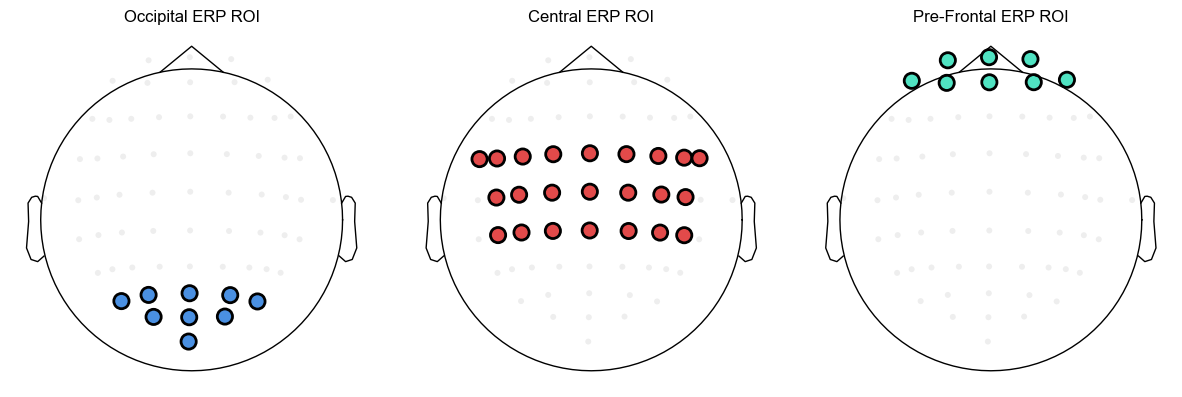

In [9]:
colors = ['#4A90E2', '#E24A4A', '#50E3C2'] 
# 2. Call our new high-level function
fig_rois, axes = plot_roi_sensors(container, rois=regions, palette=colors)
fig_rois.savefig(ARTIFACTS_DIR / 'step2_regional_topomaps.png', dpi=600, bbox_inches='tight')
fig_rois.savefig(ARTIFACTS_DIR / 'step2_regional_topomaps.svg', dpi=600, bbox_inches='tight')

## Step 3. Reshape into (Samples × Features)
To apply PCA, our 3-dimensional neural data must be carefully reshaped into a flat 2-dimensional matrix. To align with the theory from your paper, we make two crucial methodological choices here:

* <span style="color: #D55E00;"><b>Single-Trial Preservation:</b></span> To capture true biological variance, we do *not* average trials before PCA. We treat every single timepoint of every trial as a separate independent observation. 
* <span style="color: #D55E00;"><b>Subject Normalization:</b></span> Unaligned group-level PCA can be dominated by idiosyncratic subject differences. We mitigate this by exploring two types of models: a *Shared PCA* (all subjects pooled) and *Per-Subject PCAs*.

Recall from <a href="#1.-Choose-your-representation">Step 1</a> that we defined our neural state as a spatial pattern: $\mathbf{x}(t) \in \mathbb{R}^{64}$. 

<div class="alert alert-info" style="margin-top: 15px;">
<b>📦 The Tensor Flattening Math:</b><br>
When loaded, our data is a 3D tensor: <code>[Total Trials (T), Channels (C), Time (N)]</code>. <br>
<i>(Note: For simplification, the Subject dimension is absorbed into T. Specifically, <b>T = N<sub>trials per subject</sub> &times; N<sub>subjects</sub></b>!)</i><br><br>
To discover spatial topographies, we use <code>DataContainer.stack()</code> to flatten this into <code>[(T &times; N) Observations, C Features]</code>. Because <code>coco-pipe</code> tracks the metadata expansion, we can cleanly <code>unstack()</code> our 2D PCA scores back into 3D trajectories later!
</div>

Below, we stack the data **twice**: once on the pooled multi-subject container (for Step 4a), and once for each individual subject (for Step 4b).


In [10]:
# ==============================================================================
# 0. Prepare the Evoked (ERP) container
# ==============================================================================
# Create unique grouping keys combining subject and condition (e.g. "S001|3")
plot_groups = [f"{sub}|{y}" for sub, y in zip(container.coords['subject'], container.y)]

# Aggregate down to exactly 1 ERP per condition per subject
container_plot_erp = container.aggregate(by=plot_groups, stats='mean')

# Re-inject the cleaned up 'y' (condition) and 'subject' coordinates back
container_plot_erp.y = [int(g.split('|')[1]) for g in container_plot_erp.coords['obs']]
container_plot_erp.coords['subject'] = [g.split('|')[0] for g in container_plot_erp.coords['obs']]

# ==============================================================================
# 1. Pooled stacks → inputs to Shared PCA (Step 4a)
# ==============================================================================
# We will fit TWO shared PCAs in the next step to compare them!

# A. Single-Trial Pooled Stacks (Captures total biological variance)
container_plot_pooled_trials = container.stack(dims=('obs', 'time'), new_dim='obs')
print(f"Single-Trial stacked shape: {container_plot_pooled_trials.X.shape}")

# B. ERP Pooled Stacks (Captures only condition-mean shape variance)
container_plot_pooled_erp = container_plot_erp.stack(dims=('obs', 'time'), new_dim='obs')
print(f"ERP stacked shape:          {container_plot_pooled_erp.X.shape}")

# ==============================================================================
# 2. Per-subject stacks → input to per-subject PCAs (Step 4b)
# ==============================================================================
# We STRICTLY use Single Trials here for statistical testing!
per_subject_fit_stacks: dict = {}

subject_ids = np.asarray(container.coords['subject'])

for sub_id in np.unique(subject_ids):
    sub_mask = subject_ids == sub_id
    container_sub = container.isel(obs=sub_mask)
    
    per_subject_fit_stacks[sub_id] = container_sub.stack(
        dims=('obs', 'time'), new_dim='obs'
    )

print(f"\nCreated {len(per_subject_fit_stacks)} Per-Subject Single-Trial Stacks for Stats")


Single-Trial stacked shape: (173700, 64)
ERP stacked shape:          (7720, 64)

Created 10 Per-Subject Single-Trial Stacks for Stats


## Step 4. Fit the PCA Models

Because we are dealing with multiple subjects, we must be very careful about group-level alignment. We solve this by fitting **two different types of PCA models**:

#### 4a. Shared PCA (For Group-Level Figures)
We fit one global PCA on the **pooled** subject data. Every group-mean trajectory figure we generate later will live in this shared basis space. This ensures that when we look at the 3D plots, the spatial topographies mean the same thing across all subjects.

#### 4b. Per-Subject PCA (For Scalar Statistics)
We fit a separate PCA for each individual subject. We use these *per-subject* scores exclusively to compute our scalar kinematics (like trajectory speed and path length), ensuring our statistics capture true, honest within-subject variance.

<div class="alert alert-warning">
<b>⚠️ The Group-Level Alignment Caveat:</b><br>
Why don't we just use the per-subject PCAs for the 3D figures? Because Subject 1's "PC1" is not necessarily the same spatial direction as Subject 2's "PC1"—components can swap order or rotate based on individual head shapes! We use the <code>flip_pc_scores_for_consistency</code> function in Step 6 to fix <i>sign</i> flips, but it cannot fix component swaps. This is why we must maintain both a Shared PCA (for plotting) and Per-Subject PCAs (for statistics).
</div>


In [11]:
# ==============================================================================
# Step 4a: Shared PCA
# ==============================================================================
# We initialize TWO models so we can compare Single-Trial PCA vs. ERP PCA
shared_reducer_trials = DimReduction(method='PCA', n_components=N_COMPONENTS, random_state=42)
shared_reducer_erp = DimReduction(method='PCA', n_components=N_COMPONENTS, random_state=42)

# Since fitting and plotting windows are identical, we use fit_transform()!
shared_scores_trials = shared_reducer_trials.fit_transform(container_plot_pooled_trials.X)
shared_scores_erp = shared_reducer_erp.fit_transform(container_plot_pooled_erp.X)

print(f"Single-Trial shared embedding shape: {shared_scores_trials.shape}")
print(f"ERP shared embedding shape:          {shared_scores_erp.shape}")

evr_trials = shared_reducer_trials.get_diagnostics().get('explained_variance_ratio_')
evr_erp = shared_reducer_erp.get_diagnostics().get('explained_variance_ratio_')

if evr_trials is not None and evr_erp is not None:
    print(f"\nSingle-Trial cumulative variance @ 3 / 5 / 10 PCs: "
          f"{np.sum(evr_trials[:3]):.2f} / {np.sum(evr_trials[:5]):.2f} / {np.sum(evr_trials):.2f}")
    print(f"ERP cumulative variance @ 2 /  3 / 5 / 10 PCs:          "
          f" {np.sum(evr_erp[:2]):.2f}  / {np.sum(evr_erp[:3]):.2f} / {np.sum(evr_erp[:5]):.2f} / {np.sum(evr_erp):.2f}")

# ==============================================================================
# Step 4b: Per-subject PCA (Strictly Single-Trials for Stats!)
# ==============================================================================
per_subject_reducers: dict = {}
per_subject_scores: dict = {}

# Iterate over our Single-Trial stacks for statistical analysis later
for sub_id, stack in per_subject_fit_stacks.items():
    reducer = DimReduction(
        method='PCA', 
        n_components=N_COMPONENTS, 
        random_state=42
    )
    # Fit and transform the single-trial window simultaneously
    per_subject_scores[sub_id] = reducer.fit_transform(stack.X)
    per_subject_reducers[sub_id] = reducer

print(f"\nSuccessfully fit separate PCAs for {len(per_subject_reducers)} subjects.")


Single-Trial shared embedding shape: (173700, 10)
ERP shared embedding shape:          (7720, 10)

Single-Trial cumulative variance @ 3 / 5 / 10 PCs: 0.52 / 0.66 / 0.79
ERP cumulative variance @ 2 /  3 / 5 / 10 PCs:           0.52  / 0.68 / 0.80 / 0.90

Successfully fit separate PCAs for 10 subjects.


## Step 5. Select Components

How many Principal Components do we actually need? To visualize the neural dynamics **2–3 PCs typically suffice** for trajectory visualization in EEG/MEG.

We evaluate this using two methods:
1. <span style="color: #D55E00;"><b>Scree Plot:</b></span> A visual plot of the Explained Variance Ratio (EVR) per component.
2. <span style="color: #D55E00;"><b>Participation Ratio (PR):</b></span> A robust mathematical metric that gives us a single number representing the "effective dimensionality" of the dataset.

<div class="alert alert-info" style="margin-top: 15px;">
<b>🧠 What is the Participation Ratio?</b><br>
Unlike simply picking an arbitrary variance cutoff (e.g., "keep PCs until 80% variance is reached"), the Participation Ratio mathematically quantifies how many dimensions the neural data is <i>actually</i> using. If your PR is 2.4, it means your complex 64-channel neural trajectories are effectively living in a 2.4-dimensional space!
</div>

*(Note: We fit 10 components globally so that advanced users can use them later, but our downstream 3D visualizations will only utilize the top 3.)*


In [12]:
# ==============================================================================
# 1. Mathematical Metrics (Single-Trial vs. ERP)
# ==============================================================================
evr_trials_array = np.asarray(evr_trials)
evr_erp_array = np.asarray(evr_erp)

pr_trials = shared_reducer_trials.get_diagnostics().get('participation_ratio_')
pr_erp = shared_reducer_erp.get_diagnostics().get('participation_ratio_')

print("=== SINGLE-TRIAL PCA ===")
print(f"Cumulative variance at 3 PCs: {np.sum(evr_trials_array[:3]):.2%}")
if pr_trials is not None:
    print(f"Participation ratio: {pr_trials:.2f} dimensions\n")

print("=== ERP PCA ===")
print(f"Cumulative variance at 3 PCs: {np.sum(evr_erp_array[:3]):.2%}")
if pr_erp is not None:
    print(f"Participation ratio: {pr_erp:.2f} dimensions")


=== SINGLE-TRIAL PCA ===
Cumulative variance at 3 PCs: 51.90%
Participation ratio: 5.44 dimensions

=== ERP PCA ===
Cumulative variance at 3 PCs: 68.08%
Participation ratio: 4.46 dimensions


In [13]:
# ==============================================================================
# 2. Scree Plot (Single-Trial PCA)
# ==============================================================================
fig_scree_trials = plot_scree(evr_trials_array)
fig_scree_trials.update_layout(
    title='Step 5a — Scree Plot (Single Trial PCA)',
    yaxis=dict(showgrid=False),   # Turns off left axis grid lines
    yaxis2=dict(showgrid=False)   # Turns off right axis grid lines
)
fig_scree_trials.show()


In [14]:
# ==============================================================================
# 2. Scree Plot (Single-Trial PCA)
# ==============================================================================
fig_scree_trials = plot_scree(evr_erp_array)
fig_scree_trials.update_layout(
    title='Step 5a — Scree Plot (EPRs PCA)',
    yaxis=dict(showgrid=False),   # Turns off left axis grid lines
    yaxis2=dict(showgrid=False)   # Turns off right axis grid lines
)
fig_scree_trials.show()


## Step 6. Project, unstack, baseline, and align signs

Now that our PCA basis is defined, we must project our flattened, 2-dimensional data back into its original biological structure `(trials × time × components)`. We accomplish this by mapping the PCA scores back onto our `DataContainer` via `with_features`, and then calling `unstack()` to reverse the matrix reshaping we performed in [Step 3](#Step-3.-Reshape-the-dataset).

Before we can safely plot these trajectories, we must apply two critical post-processing corrections to the PC-space data:

<div class="alert alert-warning">
<b>⚠️ Why do we need post-processing in PC-space?</b><br>
PCA is a purely mathematical rotation. It does not guarantee that your neural trajectories will start at the origin $(0, 0, 0)$, nor does it guarantee that the eigenvectors (PCs) will point in a consistent direction across different subjects. We must manually enforce these constraints!
</div>

1. <span style="color: #D55E00;"><b>PC-Space Baselining:</b></span> Because we transformed the full `-0.2s` to `1.0s` window, we can use `apply_pca_score_baseline` to explicitly compute the average of the true pre-stimulus period (`-200ms` to `0ms`) and subtract it. This elegantly anchors the start of each trial's trajectory so that it originates precisely at $(0,0,0)$ exactly at the moment of stimulus onset. 
   * *Wait, didn't we already baseline in Step 2?* Yes! Step 2 centered the *raw channels* to correct for sensor drift, but the PCA rotation introduces a new mathematical offset in component space. This secondary pass anchors the *components* themselves.

2. <span style="color: #D55E00;"><b>Sign-Alignment (Per-Subject Only):</b></span> PCA eigenvectors are arbitrarily signed (i.e., a PC pointing "up" is mathematically identical to one pointing "down"). We use `flip_pc_scores_for_consistency` to flip the signs of the **per-subject** scores from [Step 4b](#Step-4b-—-Per-subject-PCA-(for-honest-per-subject-scalars)). 
   * This ensures that the downstream scalar statistics we will compute in **Step 9** are stable and directly comparable across subjects. 
   * *Note:* We do **not** sign-flip the shared PCA scores from [Step 4a](#Step-4a-—-Shared-PCA-(the-basis-the-figures-live-in)), because a single, globally shared PCA basis inherently has no cross-subject sign inconsistencies!


In [15]:
# ==============================================================================
# Step 6: Trajectory Extraction and PC-Space Baselining
# ==============================================================================
# ==============================================================================
# 1. Project & Unstack (Single-Trials vs. ERPs)
# ==============================================================================
pc_names = [f'PC{i+1}' for i in range(N_COMPONENTS)]

# A. Single-Trial Trajectories
container_pc_trials = container_plot_pooled_trials.with_features(
    shared_scores_trials, names=pc_names, new_dim_name='component'
)
container_traj_trials = container_pc_trials.unstack('obs')
print('Single-Trial Trajectories shape (trials, time, PCs):', container_traj_trials.X.shape)

# B. ERP Trajectories
container_pc_erp = container_plot_pooled_erp.with_features(
    shared_scores_erp, names=pc_names, new_dim_name='component'
)
container_traj_erp = container_pc_erp.unstack('obs')
print('ERP Trajectories shape          (trials, time, PCs):', container_traj_erp.X.shape)


Single-Trial Trajectories shape (trials, time, PCs): (900, 193, 10)
ERP Trajectories shape          (trials, time, PCs): (40, 193, 10)


In [16]:

# ==============================================================================
# 2. PC-Space Baselining
# ==============================================================================
def baseline_trajectories(container):
    """Helper function to baseline trajectories in-place."""
    times_win = np.asarray(container.coords['time'])
    for i in range(container.X.shape[0]):
        df = pd.DataFrame(container.X[i].T, index=pc_names)
        # Subtract the mean of the -0.2s to 0.0s window
        container.X[i] = apply_pca_score_baseline(
            times_win, df, baseline_min_ms=-0.2, baseline_max_ms=0.0
        ).values.T

# Apply baselining to both datasets!
baseline_trajectories(container_traj_trials)
baseline_trajectories(container_traj_erp)

print('\nBaselined Single-Trial PC1 start value:', float(container_traj_trials.X[0, 0, 0]))
print('Baselined ERP PC1 start value:         ', float(container_traj_erp.X[0, 0, 0]))


Baselined Single-Trial PC1 start value: 0.22729074317199394
Baselined ERP PC1 start value:          -1.189299826251003


In [17]:
# ==============================================================================
# 3. Sign-Align Per-Subject Scores (For Scalar Metrics Only)
# ==============================================================================
per_subject_scores_flipped: dict = {}

# Use container_plot, since we unified the fitting/plotting window!
times_win = np.asarray(container.coords['time'])

for sub_id, scores in per_subject_scores.items():
    # scores shape: (n_trials * n_time, n_components) — tile time axis to match
    n_obs = scores.shape[0]
    n_reps = n_obs // len(times_win)
    times_tiled = np.tile(times_win, n_reps)
    df = pd.DataFrame(scores.T, index=pc_names)
    
    # Flip the signs so they are mathematically consistent across subjects
    df_flipped = flip_pc_scores_for_consistency(
        scores=df, 
        time=times_tiled, 
        flip_window_ms=(0.0, 1.0) # Check polarity over the task window
    )
    
    per_subject_scores_flipped[sub_id] = df_flipped.values.T

print('\nSign-alignment complete for all subjects.')


Sign-alignment complete for all subjects.


In [18]:
# ==============================================================================
# Principal Component Traces over Time (Baselined)
# ==============================================================================
# Grab the baselined ERP dataset we just created in Step 6
y_labels_erp = np.asarray(container_traj_erp.y).astype(int)
times_arr = np.asarray(container_traj_erp.coords['time'])

# container_traj_erp.X is already shape (Trials, Time, PCs) and BASELINED!
# We just swap the last two axes to treat "PCs" as "Channels": (Trials, PCs, Time)
scores_3d = np.moveaxis(container_traj_erp.X, 2, 1)

# Treat each PC as a "Region of Interest" containing exactly 1 channel
pc_rois = {
    'PC1': ['PC1'], 
    'PC2': ['PC2'], 
    'PC3': ['PC3']
}

# Pass the data directly to ourplot_timecourses!
out = plot_timecourses(
    data=scores_3d,
    times=times_arr,
    channel_names=pc_names,
    rois=pc_rois,
    group_labels=y_labels_erp,
    group_name_map=LABEL_NAMES,
    palette=CONDITION_COLORS,
    linestyle_map=CONDITION_LINESTYLES,
    add_zero=False,
    sharey=False,
)

# 2. Handle the return types, add the title, and save accordingly
if INTERACTIVE:
    fig_pc_traces = out  
    fig_pc_traces.update_layout(title="Step 6c — Principal Component Traces over Time (Baselined ERP PCA)")
    
    # Save the figure as PNG and SVG
    fig_pc_traces.write_image('step6c_pc_traces.png', scale=2)
    fig_pc_traces.write_image('step6c_pc_traces.svg')
    
    # Display the figure in the notebook
    fig_pc_traces.show()
else:
    fig_pc_traces, axes = out 
    fig_pc_traces.suptitle('Step 6c — Principal Component Traces over Time (Baselined ERP PCA)', y=1.05, fontsize=18, fontweight='bold')
    
    # Save the figure as PNG and SVG with 600 DPI
    fig_pc_traces.savefig('step6c_pc_traces.png', dpi=600, bbox_inches='tight')
    fig_pc_traces.savefig('step6c_pc_traces.svg', dpi=600, bbox_inches='tight')
    
    # Display the figure in the notebook
    plt.show()


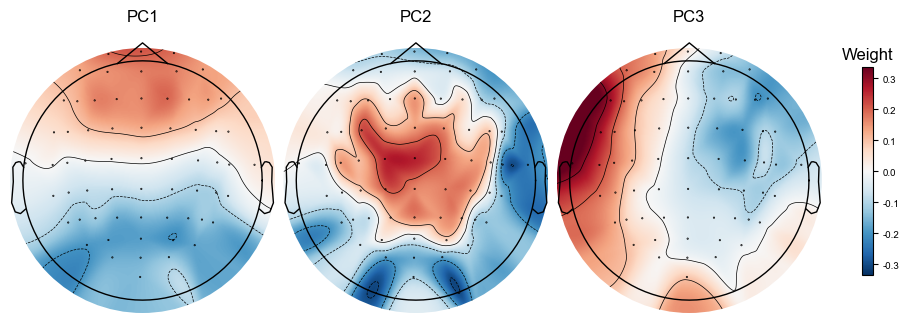

In [19]:
# ==============================================================================
# 4. PCA Spatial Loadings (Topomaps)
# ==============================================================================
import mne

n_top_pcs = 3

# The spatial weights are static and unaffected by temporal baselining!
pca_weights = shared_reducer_erp.get_components()[:n_top_pcs]
pca_weights_t = pca_weights.T 

# 1. Grab channel names directly from the container
ch_names = list(np.asarray(container.coords['channel']).astype(str))

# 2. Create a fresh info object specifically for the PCA fake-times
pca_info = mne.create_info(ch_names=ch_names, sfreq=1.0, ch_types='eeg')
pca_info.set_montage("standard_1005")

evoked_pca = mne.EvokedArray(
    pca_weights_t, 
    pca_info, 
    tmin=1 
)

# Plot the topomaps!
fig_topo = evoked_pca.plot_topomap(
    times=[1, 2, 3], 
    time_format="PC%1.0f", 
    vlim=(None, None), 
    cmap='RdBu_r',     
    colorbar=True,
    scalings=1,        
    units="Weight", size=2, res=300     
)

# Increase font sizes and colorbar width
for ax in fig_topo.axes:
    ax.title.set_fontsize(24)
    ax.tick_params(labelsize=24)
    if ax.get_ylabel():
        ax.yaxis.label.set_size(24)
        
# Make colorbar wider
cax = fig_topo.axes[-1]
box = cax.get_position()
cax.set_position([box.x0, box.y0, box.width * 2, box.height])
fig_topo.savefig('fig_topo_erp.svg', dpi=300, bbox_inches='tight')
fig_topo.savefig('fig_topo_erp.png', dpi=300, bbox_inches='tight')


## Step 7. Plot group-mean trajectories

This is the headline state-space visualization of the pipeline! 

Now that our data is properly baselined in PC-space and signed consistently, we can visualize the actual neural dynamics unfolding over time. To do this, we need to extract two things for each condition:
1. <span style="color: #0072B2;">**The Centroid Trajectory:**</span> The mathematical average of all single trials belonging to a specific condition (analogous to an ERP, but calculated in component space rather than sensor space).
2. <span style="color: #0072B2;">**The Uncertainty Envelope:**</span> The Standard Error of the Mean (SEM) calculated across trials to visualize trial-to-trial variability.

Leveraging `coco-pipe`'s multidimensional aggregation, we can compute both of these metrics simultaneously using `DataContainer.aggregate` by passing a list of statistics: `stats=['mean', 'sem']`. This elegantly returns a tensor with an added `stat` dimension containing both arrays! We then feed this straight into the `plot_trajectory` widget.

<div class="alert alert-info">
<b>💡 Interpreting the interactive plots:</b><br>
Both the 2D and 3D figures generated below are fully interactive. 
<ul>
  <li><b>2D (PC1 vs PC2):</b> Notice the translucent shading around each trajectory line. This represents the SEM envelope. It tells us how stable the neural representation is at that exact moment in time.</li>
  <li><b>3D (PC1 vs PC2 vs PC3):</b> Click and drag to rotate the axes. By examining the trajectories from different angles, you can easily spot when and where the neural representations for the 'Left Hand' and 'Right Hand' motor imagery paradigms diverge from one another. </li>
  <li><b>The Baseline Anchor:</b> Because we implemented the explicit -0.2s to 0.0s pre-stimulus baseline in Step 6, notice how all trajectories originate tightly around the (0, 0, 0) origin before branching out in response to the task!</li>
</ul>
</div>


In [20]:
# ==============================================================================
# Step 7: Prepare Trajectories for 2D/3D Plotting
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Aggregate Single-Trial Trajectories
# ------------------------------------------------------------------------------
# Aggregate across all single-trials to get the Grand Mean and Trial-Level SEM
container_traj_trials_agg = container_traj_trials.aggregate(by='y', stats=['mean', 'sem'])

traj_mean_trials = container_traj_trials_agg.X[:, 0, ...]
traj_sem_trials = container_traj_trials_agg.X[:, 1, ...]

# ------------------------------------------------------------------------------
# 2. Aggregate ERP Trajectories
# ------------------------------------------------------------------------------
# Aggregate across subject-level ERPs to get the Grand Mean and Subject-Level SEM
container_traj_erp_agg = container_traj_erp.aggregate(by='y', stats=['mean', 'sem'])

traj_mean_erp = container_traj_erp_agg.X[:, 0, ...]
traj_sem_erp = container_traj_erp_agg.X[:, 1, ...]

# ------------------------------------------------------------------------------
# 3. Extract Plotting Metadata
# ------------------------------------------------------------------------------
# We extract the condition IDs, string labels, and time axis (these are the same for both!)
condition_ids = np.asarray(container_traj_trials_agg.coords['obs']).astype(int)
condition_labels = np.array([LABEL_NAMES[y] for y in condition_ids])
color_map_str = {LABEL_NAMES[k]: v for k, v in CONDITION_COLORS.items()}
dash_map_str = {LABEL_NAMES[k]: v for k, v in CONDITION_LINESTYLES.items()}
time_axis = np.asarray(container_traj_trials_agg.coords['time'])

print("Single-Trial Mean shape (conditions, time, PCs):", traj_mean_trials.shape)
print("ERP Mean shape          (conditions, time, PCs):", traj_mean_erp.shape)

Single-Trial Mean shape (conditions, time, PCs): (4, 193, 10)
ERP Mean shape          (conditions, time, PCs): (4, 193, 10)


In [21]:
color_map_str = {LABEL_NAMES[k]: v for k, v in CONDITION_COLORS.items()}
dash_map_str = {LABEL_NAMES[k]: v for k, v in CONDITION_LINESTYLES.items()}

In [22]:
# ── DEFINE YOUR CUSTOM SCENE STYLING ──────────────────────────────────
axis_styling = dict(
    showticklabels=False,    # Completely removes the numbers!
    linewidth=4,             # Thicker bounding line
    linecolor='black',
    zeroline=False,          # Completely remove the 0-lines
    gridcolor='lightgray',
    nticks=3                 # Maximum of 3 ticks per axis
)

custom_scene = dict(
    xaxis=dict(title=dict(text='PC1', font=dict(size=35, color='black')), **axis_styling),
    yaxis=dict(title=dict(text='PC2', font=dict(size=35, color='black')), **axis_styling),
    zaxis=dict(title=dict(text='PC3', font=dict(size=35, color='black')), **axis_styling)
)

# ==============================================================================
# B. 3D Trajectories for ERP PCA
# ==============================================================================
fig_3d_erp = plot_trajectory(
    X=traj_mean_erp[..., :3],
    times=time_axis,
    labels=condition_labels,
    color_map=color_map_str,
    linestyle_map=dash_map_str,
    smooth_window=12,
    show_markers=False,
    dimensions=3,
    linewidth=10,                      # Auto-scales all trace line widths
    add_start_end_markers=True,        # Automatically calculates & adds the origin Start dot
    width=1000,                        # Native canvas width
    height=800,                        # Native canvas height
    layout_kws=dict(
        title=None,
        showlegend=False,
        scene=custom_scene,            # Injects your custom axis formatting directly
        margin=dict(l=0, r=0, b=0, t=0)
    )
)

# The 'browser' renderer pops the interactive plot open in a new Chrome/Safari tab
fig_3d_erp.show(renderer='browser', config={
    'toImageButtonOptions': {
        'format': 'png', 
        'filename': '3d_trajectory_snapshot',
        'height': 1200,      
        'width': 1500,       
        'scale': 3  
    }
})

In [23]:
# ==============================================================================
# 2. Create the 2D Figures (Pairwise Projections)
# ==============================================================================
# We will iterate through PC1vsPC2, PC1vsPC3, and PC2vsPC3 for BOTH models!

pc_pairs = [
    ([0, 1], "PC1 vs PC2"),
    ([0, 2], "PC1 vs PC3"),
    ([1, 2], "PC2 vs PC3")
]


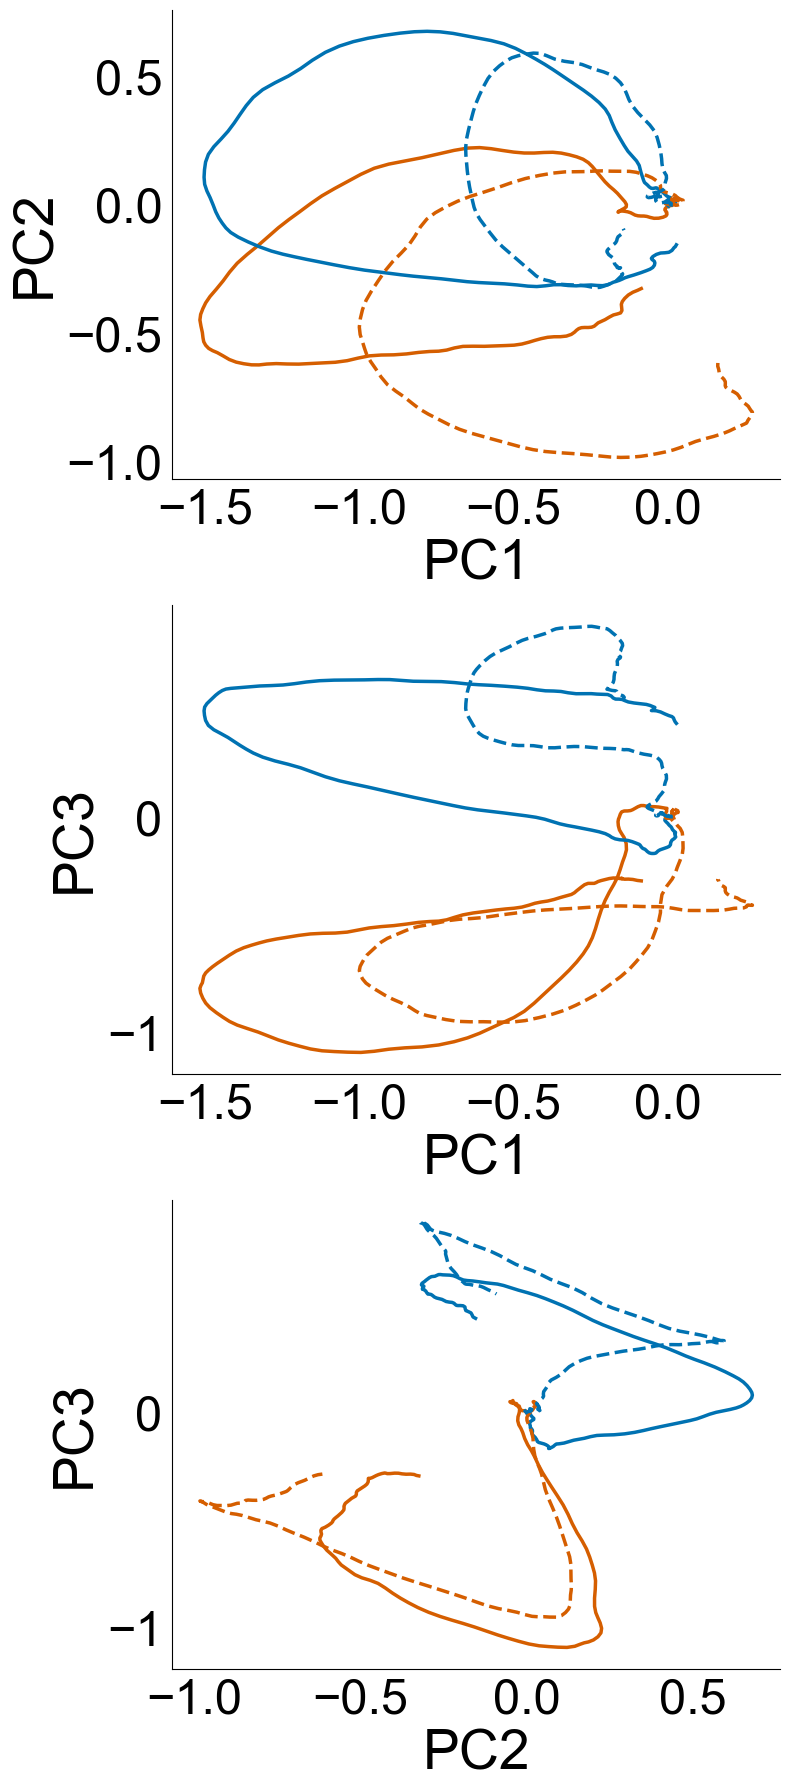

In [24]:
from coco_pipe.viz.dim_reduction import plot_trajectory as plot_trajectory_static
from coco_pipe.viz.theme import coco_theme
import matplotlib.pyplot as plt

with coco_theme():
    # ── 3 Rows, 1 Column, Tall Figsize ────────────────────────────────────────
    fig_static_erp, axes_static_erp = plt.subplots(len(pc_pairs), 1, figsize=(8, 18))
    plt.subplots_adjust(hspace=0.3) 

for i, (indices, pair_name) in enumerate(pc_pairs):
    
    with coco_theme():
        plot_trajectory_static(
            X=traj_mean_erp[..., indices],
            times=time_axis,
            labels=condition_labels,
            color_map=color_map_str,
            linestyle_map=dash_map_str,
            smooth_window=30,
            show_markers=False,
            title="",
            dimensions=2,
            ax=axes_static_erp[i],
            axis_labels=[f"PC{indices[0]+1}", f"PC{indices[1]+1}"],
            showlegend=False,
            axes_kws=dict(
                labelsize=40,                                            # Scales the X/Y labels
                tick_params=dict(labelsize=35, bottom=False, left=False), # Strips the ticks
                locator_params=dict(axis="both", nbins=4)                 # Limits the bins
            )
        )

with coco_theme():
    fig_static_erp.tight_layout()
    fig_static_erp.savefig("fig_2d_static_erp.svg", dpi=300, bbox_inches="tight")
plt.show()


## Step 8. Compare conditions

To quantify how distinct the neural representations of different cognitive tasks are, we calculate the geometric **trajectory separation** over time. 

To do this efficiently, we first wrap our projected data into a `TrajectoryResult`. This is a core analysis container in `coco-pipe` that binds the low-dimensional trajectories to their temporal coordinates, subject IDs, and condition labels. By doing this once, we unlock a unified API that allows us to effortlessly extract geometric metrics (like separation) and kinematic properties (like speed and curvature) with a single method call!

Using this container, we evaluate two different definitions of trajectory distance:
1. <span style="color: #0072B2;"><b>Euclidean (Centroid):</b></span> The raw geometric distance between the condition means in the PCA space.
2. <span style="color: #D55E00;"><b>Mahalanobis:</b></span> The distance scaled by the trial-to-trial covariance, effectively penalizing axes with high within-condition noise.

<div class="alert alert-info">
<b>💡 Interpreting Separation Metrics:</b><br>
<ul>
  <li><b>Timecourse:</b> Look for the precise moment the separation curve lifts off from zero. This is the exact latency at which the brain successfully discriminates between the two tasks!</li>
  <li><b>AUC (Area Under Curve):</b> Captures the <i>sustained</i> discriminability over the entire task window.</li>
  <li><b>Peak Separation:</b> Captures the maximum instantaneous neural divergence.</li>
</ul>
</div>

Below, we plot the full separation timecourse across the task window. Then, we extract the Peak and AUC for each individual subject, feeding them into `paired_condition_stats` to run paired t-tests (with FDR correction). This rigorously evaluates if some task pairs are statistically more separable than others!

In [25]:
from IPython.display import display
from pca_neural_trajectories import format_pair_keys
from coco_pipe.dim_reduction.evaluation.result import TrajectoryResult
import numpy as np

# ==============================================================================
# Step 8: Compare Conditions (Separation Timecourses)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Compute Separation for Single-Trial Data
# ------------------------------------------------------------------------------
# Wrap the single-trial data in the official result container
traj_res_trials = TrajectoryResult(
    trajectories=container_traj_trials.X,
    times=np.asarray(container_traj_trials.coords['time']),
    subjects=np.asarray(container_traj_trials.coords['subject']),
    conditions=np.asarray(container_traj_trials.y).astype(int)
)

# Compute separations using the built-in method
sep_timecourses_trials = traj_res_trials.get_separation_timecourses(
    methods=["centroid", "mahalanobis"]
)

# ------------------------------------------------------------------------------
# 2. Compute Separation for ERP Data
# ------------------------------------------------------------------------------
# Wrap the trial-averaged ERP data. (If your ERP container doesn't have a 'subject'
# coordinate because they are grand averages, you can just pass np.ones).
traj_res_erp = TrajectoryResult(
    trajectories=container_traj_erp.X,
    times=np.asarray(container_traj_erp.coords['time']),
    subjects=np.asarray(container_traj_erp.coords.get('subject', np.ones(container_traj_erp.X.shape[0]))),
    conditions=np.asarray(container_traj_erp.y).astype(int)
)

# We strictly use Centroid distance here to avoid covariance crashes
sep_timecourses_erp = traj_res_erp.get_separation_timecourses(
    methods=["centroid"] # Dropped mahalanobis!
)

print("Successfully computed Single-Trial separations (Centroid & Mahalanobis)!")
print("Successfully computed ERP separations          (Centroid only)!")


Successfully computed Single-Trial separations (Centroid & Mahalanobis)!
Successfully computed ERP separations          (Centroid only)!


In [26]:
exclude_pairs = [
    "Left Hand (Exec) vs Right Hand (Imag)",
    "Right Hand (Exec) vs Left Hand (Imag)"
]


In [27]:
# ==============================================================================
# Step 8a: Interactive Euclidean Separation Timecourse (Single-Trial)
# ==============================================================================

fig_euc_trials = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses_trials["centroid"], LABEL_NAMES, exclude_pairs=exclude_pairs),
    times=time_axis,
    title='Step 8a — Euclidean Separation Timecourse (Single-Trial PCA)',
    color_map=pair_color_map,
    smooth_window=10
)
fig_euc_trials.show()


In [28]:
# ==============================================================================
# Step 8b: Interactive Mahalanobis Separation Timecourse (Single-Trial)
# ==============================================================================
fig_mah_trials = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses_trials["mahalanobis"], LABEL_NAMES, exclude_pairs=exclude_pairs),
    times=time_axis,
    title='Step 8b — Mahalanobis Separation Timecourse (Single-Trial PCA)',
    color_map=pair_color_map,
    smooth_window=10  
)
fig_mah_trials.show()


In [29]:
# ==============================================================================
# Step 8c: Interactive Euclidean Separation Timecourse (ERP PCA)
# ==============================================================================
fig_euc_erp = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses_erp["centroid"], LABEL_NAMES, exclude_pairs=exclude_pairs),
    times=time_axis,
    title='Step 8c — Euclidean Separation Timecourse (ERP PCA)',
    color_map=pair_color_map,
    smooth_window=10
)
fig_euc_erp.show()


In [30]:
# ==============================================================================
# Step 8d: Statistical Validation & Scalars
# ==============================================================================

# 1. Compute per-subject Peak and AUC scalars
# We simply call the built-in method on the TrajectoryResult object we created 
# in Step 8 (traj_res_trials). This uses the single-trial data to safely 
# compute the Mahalanobis covariance!
df_sep = traj_res_trials.get_separation_pair_scalars(
    methods=["centroid", "mahalanobis"]
)

# 2. Map the raw pair strings (e.g., '3_vs_4') to readable names
df_sep['pair_name'] = df_sep['pair'].apply(
    lambda x: f"{LABEL_NAMES[int(x.split('_vs_')[0])]} vs {LABEL_NAMES[int(x.split('_vs_')[1])]}"
)

# 3. Filter out the meaningless cross-comparisons from the DataFrame!
df_sep = df_sep[~df_sep['pair_name'].isin(exclude_pairs)]

print(f"Successfully calculated scalars! DataFrame has {len(df_sep)} valid subject-level rows.")
display(df_sep.head())


Successfully calculated scalars! DataFrame has 240 valid subject-level rows.


,subject,method,pair,label_a,label_b,metric,value,pair_name
0,001,centroid,3_vs_4,3,4,peak_separation,3.608923,Left Hand (Exec) vs Right Hand (Exec)
1,001,centroid,3_vs_4,3,4,peak_separation_time,0.875000,Left Hand (Exec) vs Right Hand (Exec)
2,001,centroid,3_vs_4,3,4,auc_separation,1.939833,Left Hand (Exec) vs Right Hand (Exec)
3,001,centroid,3_vs_5,3,5,peak_separation,3.738944,Left Hand (Exec) vs Left Hand (Imag)
4,001,centroid,3_vs_5,3,5,peak_separation_time,0.862500,Left Hand (Exec) vs Left Hand (Imag)


In [31]:
# ==============================================================================
# 2. Plot Peak Separation Bar Charts
# ==============================================================================

# ------------------------------------------------------------------------------
# A. Centroid (Euclidean) Peak Separation
# ------------------------------------------------------------------------------
_peak_mask_cent = (df_sep['method'] == 'centroid') & (df_sep['metric'] == 'peak_separation')
# Use 'sem' (Standard Error of the Mean) for publication-ready error bars!
peak_by_pair_cent = df_sep.loc[_peak_mask_cent].groupby('pair_name')['value'].agg(['mean', 'sem'])

fig_peak_cent = plot_bar(
    scores=peak_by_pair_cent['mean'],
    errors=peak_by_pair_cent['sem'],
    title='Peak Separation per Pair (Centroid)',
    yaxis_title='Peak Distance (a.u.)',
)
fig_peak_cent.show()


# ------------------------------------------------------------------------------
# B. Mahalanobis Peak Separation
# ------------------------------------------------------------------------------
_peak_mask_mah = (df_sep['method'] == 'mahalanobis') & (df_sep['metric'] == 'peak_separation')
peak_by_pair_mah = df_sep.loc[_peak_mask_mah].groupby('pair_name')['value'].agg(['mean', 'sem'])

fig_peak_mah = plot_bar(
    scores=peak_by_pair_mah['mean'],
    errors=peak_by_pair_mah['sem'],
    title='Peak Separation per Pair (Mahalanobis)',
    yaxis_title='Mahalanobis Distance (D)',
)
fig_peak_mah.show()


In [32]:
# --- Plot AUC Heatmap ---
_auc_mask = df_sep['metric'] == 'auc_separation'
auc_pivot = df_sep.loc[_auc_mask].pivot_table(
    index='pair_name', columns='method', values='value', aggfunc='mean'
)

fig_auc_heat = plot_heatmap(
    auc_pivot, 
    annotate=True, 
    annotation_format='.2f',
    title='Mean AUC per pair × method',
    xaxis_title='method', 
    yaxis_title='condition pair',
)
fig_auc_heat.show()

In [33]:

# --- Interactive Paired Stats Table ---
_auc_centroid_mask = (df_sep['method'] == 'centroid') & (df_sep['metric'] == 'auc_separation')
auc_long = df_sep.loc[_auc_centroid_mask].copy()

auc_stats = paired_condition_stats(
    scalar_df=auc_long,
    conditions=list(auc_long['pair_name'].unique()),
    condition_col="pair_name",      
    subject_col="subject",
    metric_col="metric",  
    value_col="value"
)


In [34]:
print("Paired t-tests on AUC (centroid, FDR)")
display(auc_stats.style.set_table_attributes('style="font-size: 12px"'))

# The tutorial sample is illustrative; use the paper workflow for final inference.

Paired t-tests on AUC (centroid, FDR)


,metric,comparison,n,mean_diff,t,p_uncorrected,p_fdr
0,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Left Hand (Exec) vs Left Hand (Imag),10,0.315103,2.295970,0.047310,0.237353
1,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Right Hand (Exec) vs Right Hand (Imag),10,0.244449,1.242066,0.245603,0.368404
2,auc_separation,Left Hand (Exec) vs Right Hand (Exec) vs Left Hand (Imag) vs Right Hand (Imag),10,-0.110935,-0.438687,0.671231,0.671231
3,auc_separation,Left Hand (Exec) vs Left Hand (Imag) vs Right Hand (Exec) vs Right Hand (Imag),10,-0.070654,-0.459187,0.656989,0.671231
4,auc_separation,Left Hand (Exec) vs Left Hand (Imag) vs Left Hand (Imag) vs Right Hand (Imag),10,-0.426039,-1.979544,0.079118,0.237353
5,auc_separation,Right Hand (Exec) vs Right Hand (Imag) vs Left Hand (Imag) vs Right Hand (Imag),10,-0.355384,-1.701548,0.123050,0.246099


## Step 9 — Trajectory metrics & Dynamical Systems

While 3D visualizations are excellent for intuition, statistical rigor requires quantifying the geometric properties of these trajectories. We map the geometry of the neural state space to concrete cognitive interpretations using **Narrative Metrics**. 

In this step, we compute continuous time-series metrics on our group-average trajectories, visualize them as classical dynamical systems (Phase Portraits), and extract the scalars per-subject to run rigorous statistical tests.

<div class="alert alert-success">
<b>🧠 The Cognitive Interpretation Cheat Sheet:</b><br>
<ul style="margin-bottom: 0;">
  <li><b>Speed:</b> The moment-to-moment rate of change. High speed reflects rapid transitions between population states; the peak often correlates with reaction time and decision commitment.</li>
  <li><b>Phase Portraits:</b> Plotting a component's position against its own velocity. Spirals or rings mathematically prove the existence of oscillatory limit cycles in the brain.</li>
  <li><b>Path Length:</b> The total distance traveled in state space. Interpreted as the amount of representational change a condition demands (a proxy for cognitive effort).</li>
  <li><b>Tortuosity:</b> The ratio of the total path length to the straight-line displacement. High tortuosity indicates a "wandering" neural representation (e.g., due to task ambiguity).</li>
  <li><b>Dispersion (Within-Condition Spread):</b> Across-trial variability of the trajectory. Low dispersion means highly consistent neural processing.</li>
</ul>
</div>

*Note: All 13 paper-Table-2 metrics (including acceleration, curvature, and cohesion) are computed silently in the background and exported to the final CSV.*


In [35]:
from coco_pipe.viz.interactive import plot_distribution_groups
from coco_pipe.dim_reduction import trajectory_dispersion
from IPython.display import display

# ==============================================================================
# Step 10: Trajectory Metrics & Dynamical Systems
# ==============================================================================
# We strictly use the Single-Trial dataset so we have a full distribution 
# of trials (~140 per condition) to plot and run statistics on!
unique_conds = list(DEFAULT_CONDITIONS)  # All execution and imagination conditions

trial_labels = np.asarray(container_traj_trials.y).astype(int)
times_win = np.asarray(container_traj_trials.coords['time'])

# Map the integer labels to readable condition names
condition_names = [LABEL_NAMES[y] for y in trial_labels]

print(f"Ready to compute dynamical metrics for {len(trial_labels)} total single-trials!")


Ready to compute dynamical metrics for 900 total single-trials!


In [36]:
# ==============================================================================
# Step 10: Continuous Speed (Per-Condition Mean Timecourse)
# ==============================================================================
from coco_pipe.dim_reduction import trajectory_speed
import numpy as np

# 1. Compute physical speed across all single trials simultaneously
# Returns a 2D array of shape (n_trials, n_times - 1)
all_speeds = trajectory_speed(container_traj_trials.X, time=times_win)

# 2. Map the numeric labels to readable string names
condition_labels = np.array([LABEL_NAMES[int(c)] for c in container_traj_trials.y])

# 3. Interactive Plot
# `plot_trajectory_metric_series` automatically groups the 2D array by labels,
# computes the Mean, computes the SEM, and applies the smoothing window!
fig_speed = plot_trajectory_metric_series(
    series=all_speeds,
    times=times_win[1:],  
    labels=condition_labels,
    title='Step 10a — Trajectory Speed per Condition',
    ylabel='Speed (a.u./s)',
    color_map=color_map_str,
    linestyle_map=dash_map_str,
    smooth_window=10
)
fig_speed


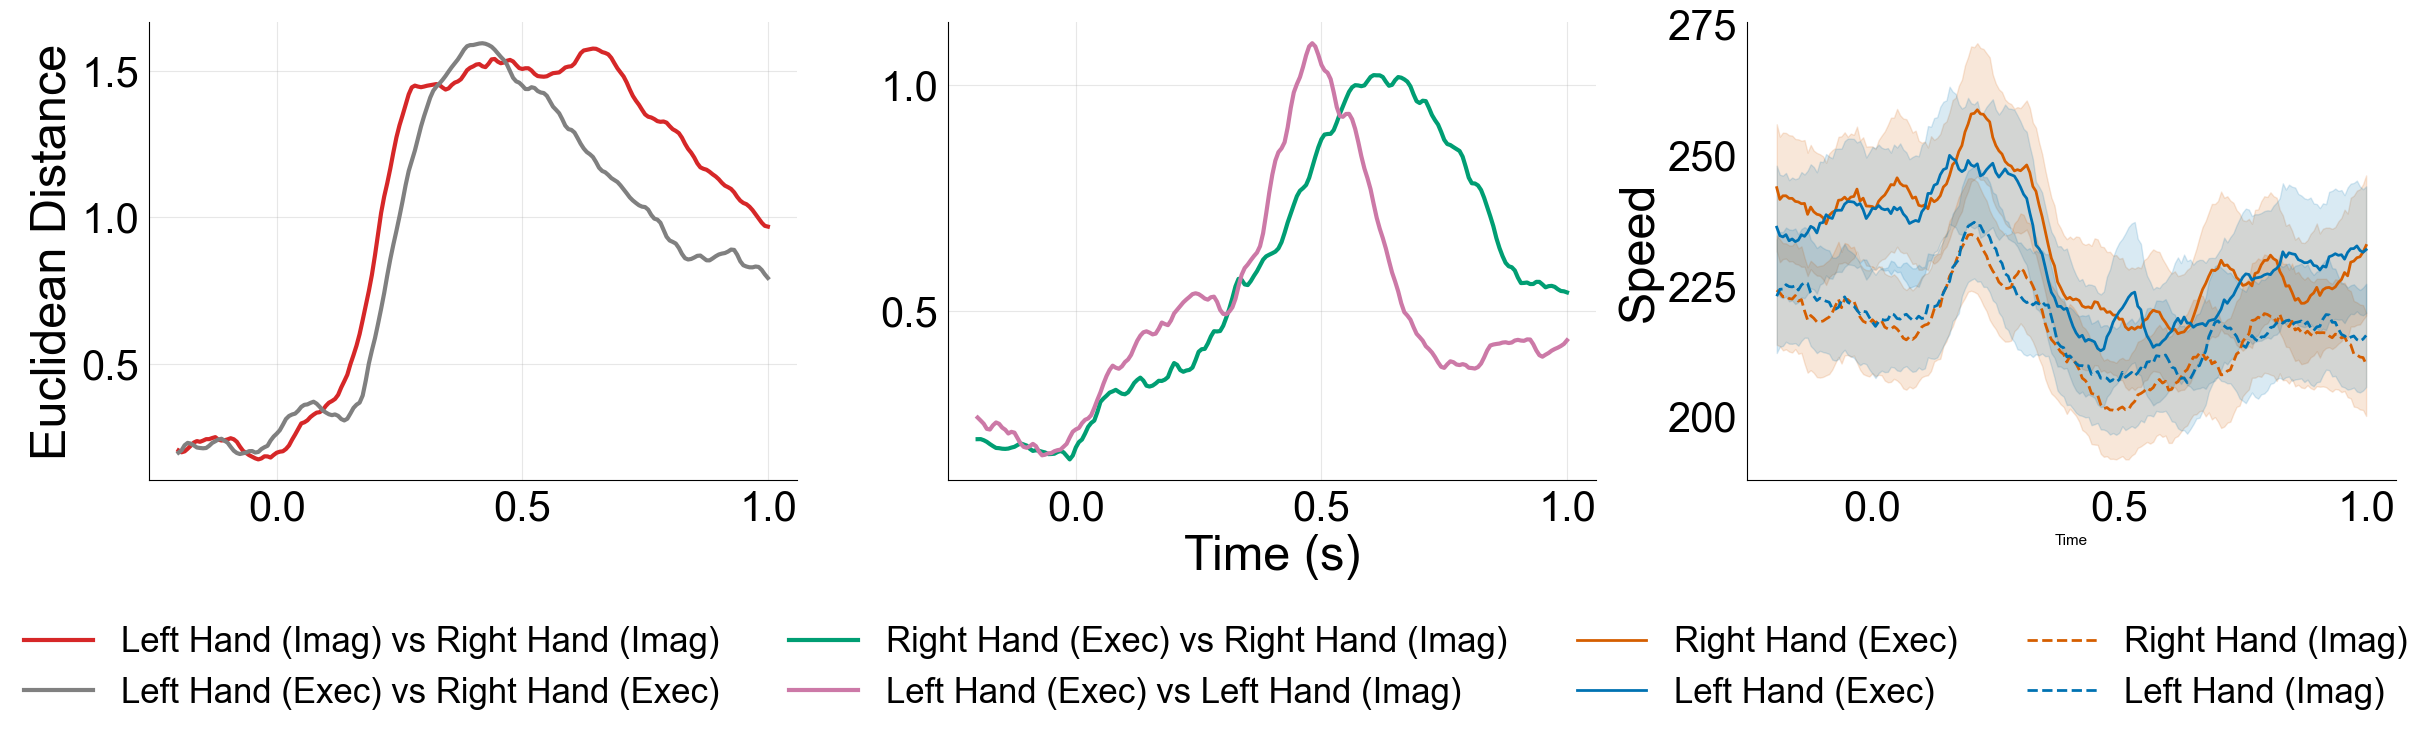

In [37]:
# ==============================================================================
# Static Multipanel Figure (For Publication)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
from coco_pipe.viz.theme import coco_theme
from pca_neural_trajectories import format_pair_keys
import coco_pipe.viz.dim_reduction as viz_static

with coco_theme():
    # 1. Setup the 1x3 Grid
    fig_static_combined, axes = plt.subplots(1, 3, figsize=(24, 6))
    plt.subplots_adjust(wspace=0.3)
    
    # 2. Format Separation Keys (using ERP Centroid here)
    sep_dict_erp = format_pair_keys(sep_timecourses_erp["centroid"], LABEL_NAMES, exclude_pairs=exclude_pairs)
    
    # Hardcoded pairs and colors for specific contrasts
    sp1_pairs = ["Left Hand (Imag) vs Right Hand (Imag)", "Left Hand (Exec) vs Right Hand (Exec)"]
    sp2_pairs = ["Right Hand (Exec) vs Right Hand (Imag)", "Left Hand (Exec) vs Left Hand (Imag)"]
    colors_sp1 = ['#d62728', 'gray']
    colors_sp2 = ['#009E73', '#CC79A7']
    
    # Helper to smooth and safely fetch pair data regardless of label order
    def smooth_sep(d, w=15):
        return pd.Series(d).rolling(window=w, min_periods=1, center=True).mean().values

    def get_sep_data(pair, sep_dict):
        if pair in sep_dict: return pair, sep_dict[pair]
        pair_alt = " vs ".join(pair.split(" vs ")[::-1])
        if pair_alt in sep_dict: return pair_alt, sep_dict[pair_alt]
        return None, None

    # --------------------------------------------------------------------------
    # Panel A: Execution vs Execution & Imagery vs Imagery Separation
    # --------------------------------------------------------------------------
    ax1 = axes[0]
    for i, pair in enumerate(sp1_pairs):
        p, data = get_sep_data(pair, sep_dict_erp)
        if data is not None:
            ax1.plot(time_axis, smooth_sep(data, 15), label=p, color=colors_sp1[i], linewidth=3)
            
    ax1.set_ylabel("Euclidean Distance", fontsize=35)
    ax1.tick_params(labelsize=30, bottom=False, left=False)
    ax1.locator_params(axis="both", nbins=4)
    
    # --------------------------------------------------------------------------
    # Panel B: Exec vs Imag (within hand) Separation
    # --------------------------------------------------------------------------
    ax2 = axes[1]
    for i, pair in enumerate(sp2_pairs):
        p, data = get_sep_data(pair, sep_dict_erp)
        if data is not None:
            ax2.plot(time_axis, smooth_sep(data, 15), label=p, color=colors_sp2[i], linewidth=3)
            
    ax2.set_xlabel("Time (s)", fontsize=35)
    ax2.tick_params(labelsize=30, bottom=False, left=False)
    ax2.locator_params(axis="both", nbins=4)

    # --------------------------------------------------------------------------
    # Panel C: Speed Timecourses (Using Native Coco-Pipe API for SEM bands)
    # --------------------------------------------------------------------------
    ax3 = axes[2]
    viz_static.plot_trajectory_metric_series(
        series=all_speeds,
        times=times_win[1:],
        labels=condition_labels,
        color_map=color_map_str,
        linestyle_map=dash_map_str,
        smooth_window=10,
        title="",
        ylabel="",
        ax=ax3
    )
    
    # Remove the automatic local legend on ax3 so we can use a master legend!
    if ax3.get_legend():
        ax3.get_legend().remove()
        
    ax3.set_ylabel("Speed", fontsize=35)
    ax3.tick_params(labelsize=30, bottom=False, left=False)
    ax3.locator_params(axis="both", nbins=4)

    # --------------------------------------------------------------------------
    # Master Legend & Formatting
    # --------------------------------------------------------------------------
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles3, labels3 = ax3.get_legend_handles_labels()
    
    all_handles = handles1 + handles2 + handles3
    all_labels = labels1 + labels2 + labels3
    
    if all_handles:
        fig_static_combined.legend(
            all_handles, all_labels, 
            loc='upper center', bbox_to_anchor=(0.5, 0.0), 
            ncol=4, fontsize=25, frameon=False
        )
    
    fig_static_combined.tight_layout()
    fig_static_combined.savefig("fig_combined_sep_speed.svg", dpi=300, bbox_inches="tight")
    
plt.show()


In [38]:
# ==============================================================================
# Interactive Euclidean Separation Timecourse (ERP PCA)
# ==============================================================================

# Notice we can now pass height, width, showlegend, margin, etc directly!
fig_euc_erp = plot_trajectory_separation(
    separation=format_pair_keys(sep_timecourses_erp["centroid"], LABEL_NAMES, exclude_pairs=exclude_pairs),
    times=time_axis,
    title='Step 8c — Euclidean Separation Timecourse (ERP PCA)',
    color_map=pair_color_map,
    smooth_window=10,
    height=500,
    width=900,
    showlegend=True,
    margin=dict(l=50, r=50, t=60, b=50)
)

fig_euc_erp.show()


In [39]:
# ==============================================================================
# 2. Dispersion (Within-Condition Spread)
# ==============================================================================

# Calculate raw dispersion using the Single-Trial dataset!
spread_dict = {
    LABEL_NAMES[c]: trajectory_dispersion(container_traj_trials.X[trial_labels == c])
    for c in unique_conds
}

# Plot directly from the raw dictionary — the API handles the smoothing and colors!
fig_spread = plot_trajectory_metric_series(
    spread_dict, 
    times=times_win,
    title='Step 10b — Within-Condition Spread (Dispersion)',
    ylabel='Within-Group Spread (a.u.)',
    color_map=color_map_str,
    linestyle_map=dash_map_str,
    smooth_window=2
)
fig_spread.show()


In [40]:
# ==============================================================================
# Distance from Baseline Origin (Trajectory Magnitude)
# ==============================================================================

# 1. Compute L2 Norm (Euclidean distance from origin) across ALL single trials at once!
# This takes trajectories of shape (trials, times, components) and returns (trials, times)
all_dists = np.linalg.norm(traj_res_trials.trajectories, axis=-1)

# 2. Plot! (The API automatically handles grouping by label, SEM calculation, and smoothing)
fig_dist = plot_trajectory_metric_series(
    series=all_dists, 
    times=times_win,
    labels=condition_labels,  # Re-using the condition labels from the Speed step!
    title='Step 10c — Distance from Baseline Origin (Magnitude)',
    ylabel='Distance from Origin (a.u.)',
    color_map=color_map_str,
    linestyle_map=dash_map_str,
    smooth_window=5
)
fig_dist.show()


In [41]:
# ==============================================================================
# Extract Scalar Metrics (Per-Subject) & Plot Distributions
# ==============================================================================
# Generate the full 13-metric statistical grid for the appendix

# Look how clean this is now!
scalar_metrics = traj_res_trials.get_per_trial_scalars()
condition_scalars = traj_res_trials.get_per_condition_scalars()

# Combine them into a single long-format DataFrame
scalar_metrics_all = pd.concat(
    [scalar_metrics.assign(level='trial'), condition_scalars.assign(level='condition')],
    ignore_index=True,
)

# Map the integer conditions to readable names
scalar_metrics_all['condition_name'] = scalar_metrics_all['condition'].map(LABEL_NAMES)

print(f"Generated {len(scalar_metrics_all)} scalar metric rows!")
display(scalar_metrics_all.head())


Generated 11780 scalar metric rows!


,subject,condition,trial,metric,value,level,condition_name
0,001,4,0.0,trajectory_length,246.701914,trial,Right Hand (Exec)
1,001,4,0.0,straight_distance,8.226093,trial,Right Hand (Exec)
2,001,4,0.0,tortuosity,29.990168,trial,Right Hand (Exec)
3,001,4,0.0,mean_speed,205.584929,trial,Right Hand (Exec)
4,001,4,0.0,max_speed,449.760301,trial,Right Hand (Exec)


In [42]:
# ==============================================================================
# Mean Path Length per Condition (Bar Chart)
# ==============================================================================

# 1. Filter our full metrics DataFrame down to just the Path Length values
_path_mask = scalar_metrics_all['metric'] == 'trajectory_length'

# 2. Automatically compute the Grand Mean and Standard Error (SEM) for each condition
path_by_cond = scalar_metrics_all.loc[_path_mask].groupby('condition_name')['value'].agg(['mean', 'sem'])

# 3. Plot
fig_path = plot_bar(
    scores=path_by_cond['mean'],
    errors=path_by_cond['sem'],
    title='Step 9 — Mean path length per condition',
    yaxis_title='Path Length (a.u.)',
)
fig_path.show()


In [43]:
# ==============================================================================
# Distributions: Tortuosity (Violin Plots)
# ==============================================================================

_tort_df = scalar_metrics_all[scalar_metrics_all['metric'] == 'tortuosity']

# 1. Use the `unique_conds` list you already defined in earlier cells
_tort_labels = [LABEL_NAMES[c] for c in unique_conds]

# 2. Extract the values for each specific condition into a list of arrays
_tort_groups = [_tort_df[_tort_df['condition_name'] == lbl]['value'].values for lbl in _tort_labels]

# 3. Pull the exact same colors from the `color_map_str` you've been using!
_tort_colors = [color_map_str[lbl] for lbl in _tort_labels]

fig_tort = plot_distribution_groups(
    groups=_tort_groups,
    labels=_tort_labels,
    kind='violin',
    color=_tort_colors,
    title='Step 9 — Trajectory Tortuosity (Neural "Wandering")',
    yaxis_title='Ratio (Path Length / Displacement)',
)
fig_tort.show()


## Step 10 — Validate (Quality Control)

Before drawing cognitive conclusions from lower-dimensional neural trajectories, we must rigorously validate that the dimensionality reduction did not destroy the true geometry of the neural state space, and that our condition separations are not merely statistical noise.

<div class="alert alert-warning">
<b>⚠️ Validation Metrics:</b><br>
<ul>
  <li><b>Trustworthiness:</b> Measures if the PCA artificially crushed distant high-dimensional states close together in 3D (false neighbors). Scores > 0.85 are considered excellent.</li>
  <li><b>Continuity:</b> Measures if the PCA artificially tore close high-dimensional neighbors far apart in 3D.</li>
  <li><b>Shepard Diagram:</b> A scatter plot of original 64D distances vs embedded 3D distances. A tight diagonal line indicates perfect distance preservation.</li>
  <li><b>Permutation Null (Separation AUC):</b> We shuffle the condition labels thousands of times to build a null distribution of trajectory separation. If our observed separation AUC is higher than the 95th percentile of the null, the neural separation is statistically significant ($p < 0.05$).</li>
</ul>
</div>


In [44]:
# ==============================================================================
# Step 10: Validate (Quality Control)
# ==============================================================================

# We subsample to max 1500 observations to keep the distance computations fast
score_n = min(1500, shared_scores_erp.shape[0])
score_idx = rng.choice(shared_scores_erp.shape[0], size=score_n, replace=False)

score_payload = shared_reducer_erp.score(
    X_emb=shared_scores_erp[score_idx, :3],        # The visual 3D space
    
    # FIX: Use the exact 2D flattened ERP sensor data you passed to `.fit()`!
    X=container_plot_pooled_erp.X[score_idx],      # The true 64D sensor space
    
    n_neighbors=min(20, score_n - 2),
    metrics=['trustworthiness', 'continuity'],
)

metrics_summary = score_payload.get('metrics', {})
print('Embedding Quality:', metrics_summary)


Embedding Quality: {'trustworthiness': 0.8719208120675968, 'continuity': 0.9293253714415334}


In [45]:
# ==============================================================================
# 2. Shepard Diagram (Distance Preservation)
# ==============================================================================
# We restrict sample_size=300 to prevent the massive 2D contour trace from 
# serializing ~19MB of data and freezing the web browser during HTML export!

fig_shepard = plot_shepard_diagram(
    X_orig=container_plot_pooled_erp.X[score_idx],
    X_emb=shared_scores_erp[score_idx, :3],
    sample_size=300,
    title='Step 10 — Shepard diagram (3D vs 64D)',
)
fig_shepard.show()


In [46]:
# ==============================================================================
# 3. Statistical Significance: Permutation Null on Separation AUC
# ==============================================================================

# We test a complex contrast: Unilateral (Left/Right) vs Bilateral (Hands/Feet)
obs_auc, null_auc = permutation_null_separation_auc(
    result=traj_res_trials,  # <--- Just pass the unified container directly!
    group_a=[3, 4],          # Unilateral Exec
    group_b=[7, 8],          # Bilateral Exec
    n_perm=200,
    rng=rng,
    window=(0.0, 1.0),       # Only evaluate separation during the active task!
)

obs_auc, null_auc

(nan, array([], dtype=float64))

In [47]:
# ==============================================================================
# 3. Statistical Significance: Permutation Null on Separation AUC
# ==============================================================================

obs_auc, null_auc = permutation_null_separation_auc(
    result=traj_res_trials,      
    
    # Compare Execution vs Imagination
    group_a=[3, 4],   # Left/Right Exec
    group_b=[5, 6],   # Left/Right Imag
    
    n_perm=200,
    rng=rng,
    window=(0.0, 1.0), 
)

# Calculate exact empirical p-value
p_value = float((np.sum(null_auc >= obs_auc) + 1) / (len(null_auc) + 1))
print(f'Observed AUC = {obs_auc:.3f}; Null p-value = {p_value:.3f}')

# Plot the Null Distribution vs our Observed Statistic
_null_frame = pd.DataFrame({
    "Model": ["PCA Trajectory"],
    "Metric": ["AUC"],
    "Observed": [obs_auc],
    "NullLower": [float(np.percentile(null_auc, 2.5))],
    "NullUpper": [float(np.percentile(null_auc, 97.5))],
})
fig_null = plot_null_interval_summary(
    _null_frame,
    title=f'Step 10 — Permutation Null (Exec vs Imag)<br>Empirical p-value: {p_value:.3f}',
)
fig_null.show()


Observed AUC = 0.498; Null p-value = 0.025
